In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import tensorflow as tf
from keras.models import Model
from keras.layers import Input, Dense, Dropout, BatchNormalization, Conv1D, Add, Activation, GlobalAveragePooling1D, MultiHeadAttention, LayerNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import AdamW
from keras.regularizers import l2
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
import ta

# Set random seeds for reproducibility
RANDOM_SEED = 23
tf.random.set_seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
## Parameters
META_CLASSIFIER = 'xgb'  # Options: 'rf', 'svm', 'xgb'
WINDOW_LENGTH = 14
NUM_CLASSES = 3
INVESTMENT_RATE = 1 ## Keep
DO_BALANCING_SLECTION = False
data_dir = "../data"

## Best performance with W=14, N=3 - 25, 15 on s_1, 

MODEL = None

Meta classifier Notes
1. SVM - Accurate, but less generalizable - strong bias in confusion matrix for some data.
2. RF - Innacurate and strong bias

In [3]:
# Data Loadin
print("Fetching Ethereum data...")
eth_data = yf.download('ETH-USD', start='2021-01-01', end='2023-01-01', interval='1d')
eth_data.columns = [col[0] if isinstance(col, tuple) else col for col in eth_data.columns]

price_history = eth_data.reset_index().rename(columns={
    'Date': 'timeOpen', 'Close': 'close', 'Open': 'open',
    'High': 'high', 'Low': 'low', 'Volume': 'volume'
})

# Convert to numeric and handle NaNs
price_history['close'] = pd.to_numeric(price_history['close'], errors='coerce')
price_history['close'] = price_history['close'].interpolate(method='linear', limit_direction='both')
price_history['timeOpen'] = pd.to_datetime(price_history['timeOpen'])
price_history['date'] = price_history['timeOpen'].dt.date

print(f"Loaded {len(price_history)} days of price data")

# Data Engineering and feature creation
price_history['delta'] = price_history['close'].pct_change()

# Lagged features
price_history['lag1_delta'] = price_history['delta'].shift(1, fill_value=0)
price_history['lag2_delta'] = price_history['delta'].shift(2, fill_value=0)

price_history['volatility'] = price_history['delta'].shift(1).rolling(window=7).std()
price_history['volume_delta'] = price_history['volume'].shift(1).pct_change()
## Volume is extracted from day before, and is thus only avaliable shifted back 1

# Technical indicators: shifted to use previous day's values
# price_history['rsi'] = ta.momentum.RSIIndicator(price_history['close'], window=14).rsi().shift(1)
# price_history['macd'] = ta.trend.MACD(price_history['close']).macd().shift(1)

# bb = ta.volatility.BollingerBands(price_history['close'])
# price_history['bb_upper'] = bb.bollinger_hband().shift(1)
# price_history['bb_lower'] = bb.bollinger_lband().shift(1)

# price_history['obv'] = ta.volume.OnBalanceVolumeIndicator(
#     price_history['close'], 
#     price_history['volume']
# ).on_balance_volume().shift(1)

# Fill NaN values
feature_cols = ['lag1_delta', 'lag2_delta', 'volatility', 'volume_delta',
                # 'rsi', 'macd', 'bb_upper', 'bb_lower', 'obv'
                ]
price_history[feature_cols] = price_history[feature_cols].ffill().bfill()

Fetching Ethereum data...
YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Loaded 730 days of price data


Loaded whale data: 67100 records
Loaded validator data: 193391 records
Generating price movement labels...
Generating 3-class labels using quantiles for balanced classes...
Label thresholds (quantiles): [-0.27200349 -0.01466324  0.01822854  0.25947533]


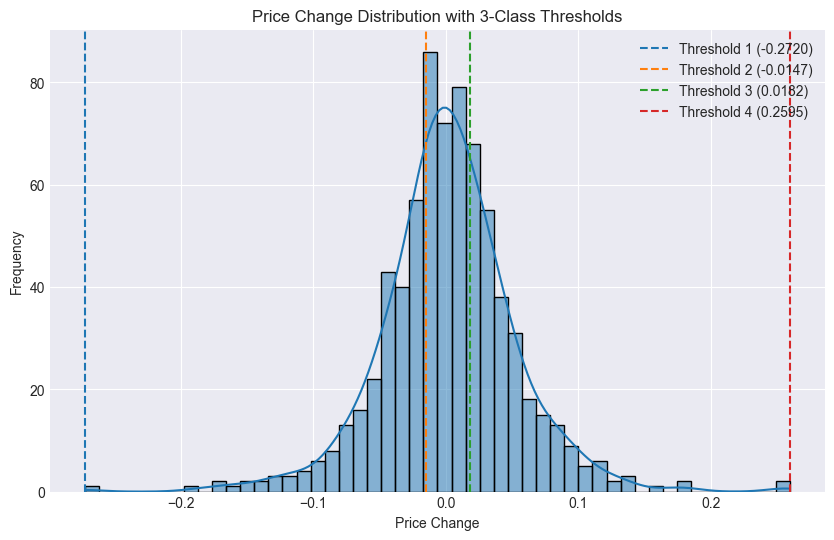

In [4]:
whales = pd.read_csv(os.path.join(data_dir, 'transactions_aggregated_21_22.csv'))
validators = pd.read_csv(os.path.join(data_dir, 'validators_aggregated_21_22.csv'))

whales['date'] = pd.to_datetime(whales['datetime']).dt.date
validators['date'] = pd.to_datetime(validators['datetime']).dt.date

print(f"Loaded whale data: {len(whales)} records")
print(f"Loaded validator data: {len(validators)} records")

print("Generating price movement labels...")
price_changes = price_history['close'].pct_change()

# Dynamically create labels based on NUM_CLASSES
print(f"Generating {NUM_CLASSES}-class labels using quantiles for balanced classes...")
label_thresholds = price_changes.quantile(np.linspace(0, 1, NUM_CLASSES + 1)).values
price_history['labels'] = np.digitize(price_changes, bins=label_thresholds[1:-1], right=True) # np.digitize assigns bins: 0, 1, ..., NUM_CLASSES-1
print("Label thresholds (quantiles):", label_thresholds)

# # Visualize thresholds
plt.figure(figsize=(10, 6))
sns.histplot(price_changes.dropna(), bins=50, kde=True)
for i, thresh in enumerate(label_thresholds):
    plt.axvline(thresh, color='C{}'.format(i), linestyle='--', label=f'Threshold {i+1} ({thresh:.4f})')
plt.title(f'Price Change Distribution with {NUM_CLASSES}-Class Thresholds')
plt.xlabel('Price Change')
plt.ylabel('Frequency')
plt.legend()
plt.show()


# Aggregate whale and validator data
whale_agg = whales.groupby('date').agg(
    whale_avg_valueEth=('valueETH', 'mean'),
    whale_var_valueEth=('valueETH', 'var'),
    whale_avg_gasPrice=('gasPrice', 'mean')
)

validator_agg = validators.groupby('date').agg(
    validator_count=('blockHash', 'nunique'),
    validator_gas_price=('gasPrice', 'mean')
)

validator_agg['validator_count_avg'] = validator_agg['validator_count'].rolling(window=7, min_periods=1).mean()

# Merge all data
labeled_data = price_history.merge(whale_agg, on='date', how='left')
labeled_data = labeled_data.merge(validator_agg, on='date', how='left')

# Define final feature set
all_features = [
    'whale_avg_valueEth', 'whale_var_valueEth', 'whale_avg_gasPrice',
    'validator_count', 'validator_gas_price', 'lag1_delta', 'lag2_delta',
    "validator_count_avg",
    # 'volatility', 'volume_delta', 'rsi',
    # 'macd', 'bb_upper', 'bb_lower', 'obv'
]

# Fill remaining NaNs
labeled_data[all_features] = labeled_data[all_features].ffill().bfill()
labeled_data.dropna(subset=['labels'], inplace=True)
labeled_data.sort_values(by='date', inplace=True)

# print(f"Final dataset shape: {labeled_data.shape}")
# print(f"Features: {len(all_features)}")

In [5]:
# Data Preparation
print("Preparing data for training...")
y = labeled_data['labels'].astype(int)
X = labeled_data[all_features]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, shuffle=False
)

print(X.head(4))

if DO_BALANCING_SLECTION:
    # Balance the training set by random undersampling
    min_count = y_train.value_counts().min()
    balanced_indices = (
        # For each label, randomly sample min-count 
        y_train.groupby(y_train).apply(lambda x: x.sample(min_count, random_state=RANDOM_SEED)).index.get_level_values(1)) 
    X_train = X_train.loc[balanced_indices]
    y_train = y_train.loc[balanced_indices]

#Scale features
# scaler = RobustScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

# Create sliding windows for time series modeling
def create_windows(data, window_size):
    windows = []
    for i in range(len(data) - window_size + 1):
        windows.append(data[i:i + window_size])
    return np.array(windows)

X_train_windowed = create_windows(X_train, WINDOW_LENGTH)
X_test_windowed = create_windows(X_test, WINDOW_LENGTH)
y_train_windowed = y_train.iloc[WINDOW_LENGTH-1:].values
y_test_windowed = y_test.iloc[WINDOW_LENGTH-1:].values

print(f"Windowed training: X={X_train_windowed.shape}, y={y_train_windowed.shape}")
print(f"Windowed testing: X={X_test_windowed.shape}, y={y_test_windowed.shape}")

# Get aligned price deltas for backtesting
price_deltas_test = labeled_data['delta'].loc[y_test.index[WINDOW_LENGTH-1:]].to_numpy()
price_deltas_train = labeled_data['delta'].loc[y_train.index[WINDOW_LENGTH-1:]].to_numpy()

Preparing data for training...
   whale_avg_valueEth  whale_var_valueEth  whale_avg_gasPrice  \
0         9420.615145        2.907903e+08        9.104290e+10   
1         5493.719855        2.406098e+07        1.310462e+11   
2        13325.784826        1.492609e+08        2.976456e+11   
3        18190.842405        1.977588e+08        3.516557e+11   

   validator_count  validator_gas_price  lag1_delta  lag2_delta  \
0            215.0         6.305435e+10    0.000000    0.000000   
1             91.0         1.036428e+11    0.000000    0.000000   
2            138.0         1.679290e+11    0.060473    0.000000   
3            140.0         1.924708e+11    0.259475    0.060473   

   validator_count_avg  
0                215.0  
1                153.0  
2                148.0  
3                146.0  
Windowed training: X=(571, 14, 8), y=(571,)
Windowed testing: X=(133, 14, 8), y=(133,)


In [6]:
def residual_block(x, filters, kernel_size, dilation_rate, dropout_rate=0.3):
    """Residual block for TCN model"""
    prev_x = x
    if x.shape[-1] != filters:
        prev_x = Conv1D(filters, kernel_size=1, padding='same', kernel_regularizer=l2(0.01))(prev_x)
    
    conv1 = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding='causal', kernel_regularizer=l2(0.01))(x)
    conv1 = BatchNormalization()(conv1)
    conv1 = Activation('relu')(conv1)
    conv1 = Dropout(dropout_rate)(conv1)
    
    conv2 = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding='causal', kernel_regularizer=l2(0.01))(conv1)
    conv2 = BatchNormalization()(conv2)
    conv2 = Activation('relu')(conv2)
    conv2 = Dropout(dropout_rate)(conv2)
    
    out = Add()([prev_x, conv2])
    out = Activation('relu')(out)
    return out

def build_tcn_model(window_length, input_features, num_classes):
    """Build Temporal Convolutional Network"""
    inputs = Input(shape=(window_length, input_features))
    x = inputs
    
    # Stack residual blocks with different dilation rates
    for d in [1, 2]:
        x = residual_block(x, filters=16, kernel_size=3, dilation_rate=d)
    
    x = GlobalAveragePooling1D()(x)
    outputs = Dense(num_classes, activation='softmax', kernel_regularizer=l2(0.01))(x)
    
    return Model(inputs, outputs, name="TCN")

def build_transformer_model(window_length, input_features, num_classes):
    """Build Transformer model"""
    inputs = Input(shape=(window_length, input_features))
    x = inputs
    
    # Single transformer layer
    attn_output = MultiHeadAttention(num_heads=2, key_dim=16)(x, x)
    x = LayerNormalization(epsilon=1e-6)(x + attn_output)
    
    # Feed-forward network
    ffn = Dense(32, activation='relu', kernel_regularizer=l2(0.01))(x)
    ffn = Dense(input_features, kernel_regularizer=l2(0.01))(ffn)
    x = LayerNormalization(epsilon=1e-6)(x + ffn)
    
    x = GlobalAveragePooling1D()(x)
    outputs = Dense(num_classes, activation='softmax', kernel_regularizer=l2(0.01))(x)
    
    return Model(inputs, outputs, name="Transformer")

def train_keras_model(model, X_train, y_train, X_test, tscv, epochs=100, batch_size=64):
    """Train Keras model with time series cross-validation"""
    train_preds = np.zeros(len(y_train))
    test_preds_list = []
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        # print(f"Training fold {fold + 1}...")
        
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]
        
        # Clone model for each fold
        model_fold = tf.keras.models.clone_model(model)
        model_fold.compile(
            optimizer=AdamW(learning_rate=0.0005),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        
        # Calculate class weights
        class_weights = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
        class_weight_dict = dict(enumerate(class_weights))
        
        # Train model
        model_fold.fit(
            X_tr, y_tr,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(X_val, y_val),
            callbacks=[
                EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
                ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=0)
            ],
            class_weight=class_weight_dict,
            verbose=0
        )
        
        # Predictions
        train_preds[val_idx] = np.argmax(model_fold.predict(X_val, verbose=0), axis=1)
        test_preds_list.append(np.argmax(model_fold.predict(X_test, verbose=0), axis=1))
    
    # Average test predictions across folds
    test_preds = np.mean(test_preds_list, axis=0).round().astype(int)
    return train_preds, test_preds

def train_sklearn_model(model, X_train, y_train, X_test, tscv):
    """Train sklearn model with time series cross-validation"""
    train_preds = np.zeros(len(y_train))
    test_preds_list = []
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        # print(f"Training fold {fold + 1}...")
        
        # Flatten data for sklearn models
        X_tr = X_train[train_idx].reshape(len(train_idx), -1)
        X_val = X_train[val_idx].reshape(len(val_idx), -1)
        y_tr, y_val = y_train[train_idx], y_train[val_idx]
        
        model.fit(X_tr, y_tr)
        train_preds[val_idx] = model.predict(X_val)
        test_preds_list.append(model.predict(X_test.reshape(len(X_test), -1)))
    
    # Majority vote for test predictions
    test_preds = np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=test_preds_list)
    return train_preds, test_preds

def calculate_backtest_returns(predictions, price_deltas, plot_results=True):
    """Calculate returns from trading strategy based on predictions
    
    Predictions in [0:NUM_LABELS - 1]
    """
    model_history = [1]  # Start with $1.00
    benchmark_history = [1]
    positions = []
    
    for i in range(len(predictions)):
        if np.isnan(price_deltas[i]):
            # Handle ends of data NANs
            benchmark_history.append(benchmark_history[-1])
            model_history.append(model_history[-1])
            positions.append(0)
            continue
        
        # Calculate buy and hold value
        benchmark_history.append(benchmark_history[-1] * (1 + price_deltas[i]))
        
        # Calculate model value based on prediction
        # if predictions[i] + 1 >= NUM_CLASSES - (NUM_CLASSES // 2):
        if predictions[i] > (NUM_CLASSES -1) // 2:
            delta_i = max(price_deltas[i], -0.05)
            capital_change = model_history[-1] * delta_i * INVESTMENT_RATE
            model_history.append(model_history[-1] + capital_change)
            positions.append(1)
        else:
            model_history.append(model_history[-1])
            positions.append(0)
    
    total_return = (model_history[-1] - 1) * 100
    benchmark_return = (benchmark_history[-1] - 1) * 100
    
    if plot_results:
        plt.figure(figsize=(12, 6))
        plt.plot(model_history, label='Model Strategy', color='blue', linewidth=2)
        plt.plot(benchmark_history, label='Buy & Hold', color='black', linestyle='--', linewidth=2)
        
        # Color code investment levels
        for i, pos in enumerate(positions):
            if pos == 1:
                plt.axvspan(i, i + 1, color='green', alpha=0.3)
        
        plt.title(f'Trading Strategy Results\nModel: {total_return:.2f}% | Benchmark: {benchmark_return:.2f}%')
        plt.xlabel('Trading Days')
        plt.ylabel('Capital Value')
        plt.grid(True, alpha=0.2)
        plt.legend()
        plt.show()
    
    # Calculate average daily return
    daily_returns = np.diff(model_history) / model_history[:-1]
    avg_daily_return = np.mean(daily_returns) * 100  # Convert to percentage

    # Calculate percent of days invested
    percent_days_invested = (np.sum(np.array(positions) > 0) / len(positions)) * 100

    print(f"Average Daily Return: {avg_daily_return:.2f}%")
    print(f"Percent of Days Invested: {percent_days_invested:.2f}%")

    return {
        'model_return': total_return,
        'benchmark_return': benchmark_return,
        'avg_daily_return': avg_daily_return,
        'percent_days_invested': percent_days_invested,
    }
    

def train_stacking_ensemble(X_train_windowed, y_train_windowed, X_test_windowed):
    """Train the complete stacking ensemble"""
    print("\n=== Training Stacking Ensemble ===")
    
    # Initialize time series cross-validator
    tscv = TimeSeriesSplit(n_splits=5)
    
    # Initialize base models
    print("\nInitializing base models...")
    tcn_model = build_tcn_model(WINDOW_LENGTH, X_train_windowed.shape[2], NUM_CLASSES)
    transformer_model = build_transformer_model(WINDOW_LENGTH, X_train_windowed.shape[2], NUM_CLASSES)
    xgb_model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.2, random_state=RANDOM_SEED)
    
    # Train base models and get predictions
    print("\nTraining TCN model...")
    tcn_train_preds, tcn_test_preds = train_keras_model(
        tcn_model, X_train_windowed, y_train_windowed, X_test_windowed, tscv
    )
    
    print("\nTraining Transformer model...")
    transformer_train_preds, transformer_test_preds = train_keras_model(
        transformer_model, X_train_windowed, y_train_windowed, X_test_windowed, tscv
    )
    
    print("\nTraining XGBoost model...")
    xgb_train_preds, xgb_test_preds = train_sklearn_model(
        xgb_model, X_train_windowed, y_train_windowed, X_test_windowed, tscv
    )
    
    # Create meta-features from base model predictions
    print("\nCreating meta-features...")
    train_meta_features = np.column_stack((tcn_train_preds, transformer_train_preds, xgb_train_preds))
    test_meta_features = np.column_stack((tcn_test_preds, transformer_test_preds, xgb_test_preds))
    
    # Initialize and train meta-classifier
    print(f"\nTraining meta-classifier: {META_CLASSIFIER.upper()}...")
    if META_CLASSIFIER == 'rf':
        meta_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_SEED)
    elif META_CLASSIFIER == 'svm':
        meta_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=RANDOM_SEED)
    elif META_CLASSIFIER == 'xgb':  # xgb
        meta_model = XGBClassifier(n_estimators=100, max_depth=2, learning_rate=0.2, random_state=RANDOM_SEED)
    # elif META_CLASSIFIER == '':
    
    meta_model.fit(train_meta_features, y_train_windowed)
    
    # Make final predictions
    train_predictions = meta_model.predict(train_meta_features)
    test_predictions = meta_model.predict(test_meta_features)

    return train_predictions, test_predictions

In [7]:
# Train the ensemble
train_predictions, test_predictions = train_stacking_ensemble(X_train_windowed, y_train_windowed, X_test_windowed)


=== Training Stacking Ensemble ===

Initializing base models...

Training TCN model...

Training Transformer model...

Training XGBoost model...

Creating meta-features...

Training meta-classifier: XGB...


Train prediction distribution:
Label 0: 330 (57.79%)
Label 1: 94 (16.46%)
Label 2: 147 (25.74%)
Test prediction distribution:
Label 0: 41 (30.83%)
Label 1: 45 (33.83%)
Label 2: 47 (35.34%)
Test Accuracy: 0.3233
Test F1 Score: 0.3253

Classification Report:
              precision    recall  f1-score   support

           1       0.24      0.28      0.26        36
           2       0.42      0.30      0.35        63
           3       0.30      0.41      0.35        34

    accuracy                           0.32       133
   macro avg       0.32      0.33      0.32       133
weighted avg       0.34      0.32      0.33       133



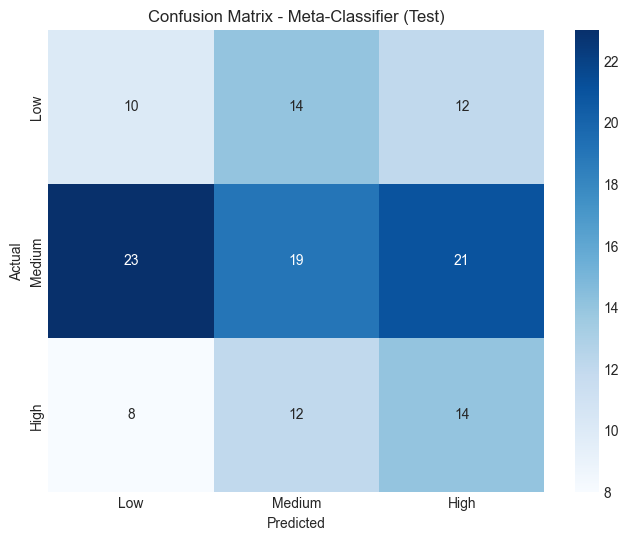

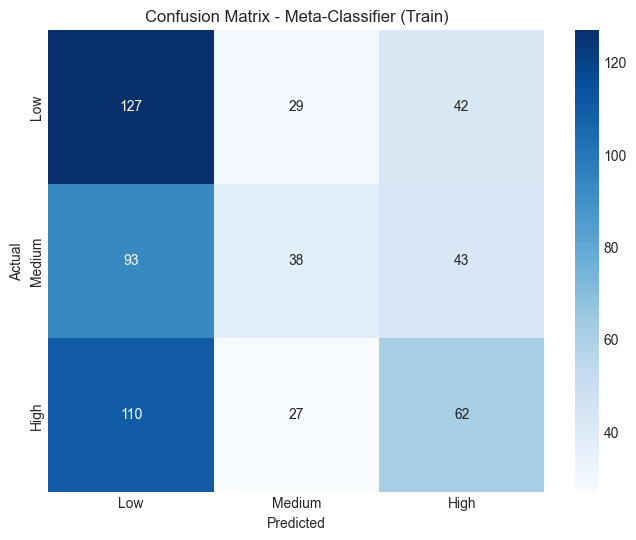

In [8]:
# Print distribution of training and testing predictions
num_labels = NUM_CLASSES
print("Train prediction distribution:")
for i in range(num_labels):
    print(f"Label {i}: {(train_predictions == i).sum()} ({(train_predictions == i).mean()*100:.2f}%)")
print("Test prediction distribution:")
for i in range(num_labels):
    print(f"Label {i}: {(test_predictions == i).sum()} ({(test_predictions == i).mean()*100:.2f}%)")

# Calculate metrics
train_accuracy = accuracy_score(y_train_windowed, train_predictions)
test_accuracy = accuracy_score(y_test_windowed, test_predictions)
f1 = f1_score(y_test_windowed, test_predictions, average='weighted')
class_report = classification_report(y_test_windowed, test_predictions, 
                                   target_names=[str(x + 1) for x in range(NUM_CLASSES)], 
                                   zero_division=0)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(class_report)

# 
# trix for test set
plt.figure(figsize=(8, 6))
conf_matrix = confusion_matrix(y_test_windowed, test_predictions)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.title(f'Confusion Matrix - Meta-Classifier (Test)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Confusion matrix for train set
plt.figure(figsize=(8, 6))
conf_matrix_train = confusion_matrix(y_train_windowed, train_predictions)
sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.title(f'Confusion Matrix - Meta-Classifier (Train)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


=== Backtesting Test Data Results ===


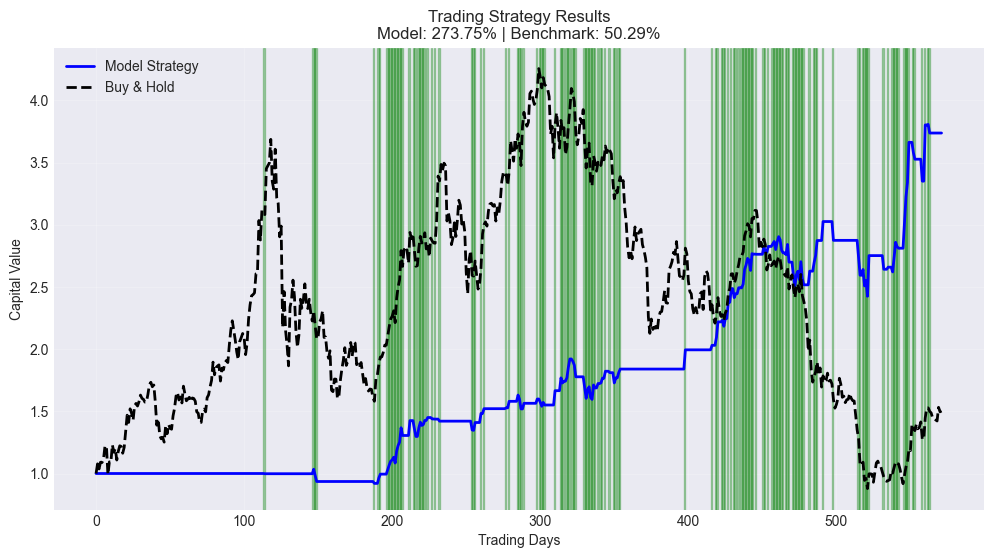

Average Daily Return: 0.25%
Percent of Days Invested: 25.74%
Model Return: 273.75%
Benchmark Return: 50.29%
Average Daily Return: 0.25%
Percent of days invested: 25.74%


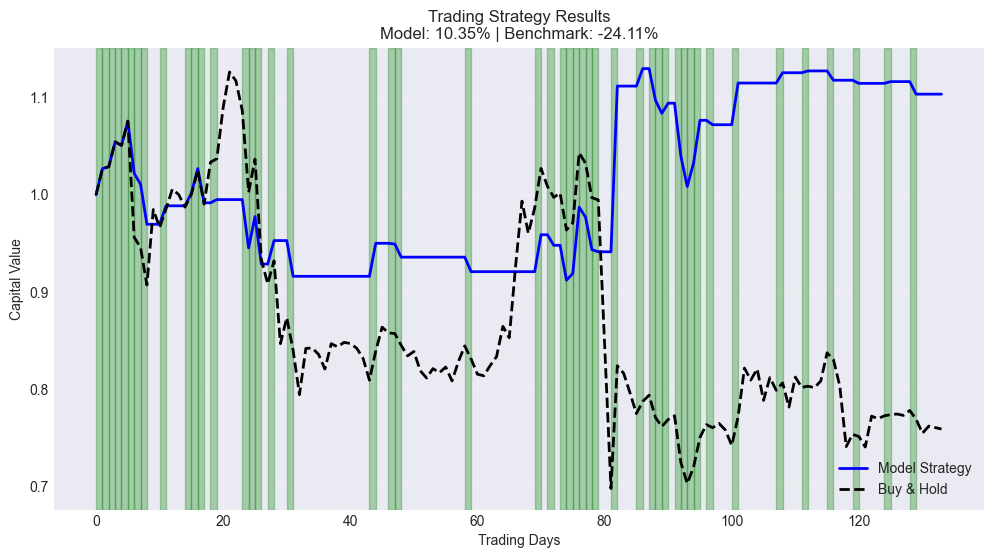

Average Daily Return: 0.10%
Percent of Days Invested: 35.34%
Model Return: 10.35%
Benchmark Return: -24.11%
Average Daily Return: 0.10%
Percent of days invested: 35.34%


In [9]:
# Backtesting
print("\n=== Backtesting Test Data Results ===")

backtest_train = calculate_backtest_returns(train_predictions, price_deltas_train) ## Training dont show
print(f"Model Return: {backtest_train['model_return']:.2f}%")
print(f"Benchmark Return: {backtest_train['benchmark_return']:.2f}%")
print(f"Average Daily Return: {backtest_train['avg_daily_return']:.2f}%")
print(f"Percent of days invested: {backtest_train['percent_days_invested']:.2f}%")

backtest_test = calculate_backtest_returns(test_predictions, price_deltas_test)
print(f"Model Return: {backtest_test['model_return']:.2f}%")
print(f"Benchmark Return: {backtest_test['benchmark_return']:.2f}%")
print(f"Average Daily Return: {backtest_test['avg_daily_return']:.2f}%")
print(f"Percent of days invested: {backtest_test['percent_days_invested']:.2f}%")

In [10]:
validators_current = pd.read_csv(os.path.join(data_dir, "validators_aggregated_current.csv"))
transactions_current = pd.read_csv(os.path.join(data_dir, "transactions_aggregated_current.csv"))

# Process and prepare current data
validators_current['date'] = pd.to_datetime(validators_current['datetime']).dt.date
transactions_current['date'] = pd.to_datetime(transactions_current['datetime']).dt.date

# Aggregate current whale/validator data by date
whale_agg_current = transactions_current.groupby('date').agg(
    whale_avg_valueEth=('valueETH', 'mean'),
    whale_var_valueEth=('valueETH', 'var'),
    whale_avg_gasPrice=('gasPrice', 'mean')
)

validator_agg_current = validators_current.groupby('date').agg(
    validator_count=('blockHash', 'nunique'),
    validator_gas_price=('gasPrice', 'mean')
)

validator_agg_current['validator_count_avg'] = validator_agg_current['validator_count'].rolling(window=7, min_periods=1).mean()

# Get the date range for current data
current_dates = sorted(list(set(validators_current['date'].tolist() + transactions_current['date'].tolist())))
print(f"Current data date range: {min(current_dates)} to {max(current_dates)}")

# Fetch corresponding price data for the same period
print("Fetching corresponding price data...")
start_date = min(current_dates)
end_date = max(current_dates)

# Convert datetime.date to string for yfinance
start_str = start_date.strftime('%Y-%m-%d')
end_str = (end_date + pd.Timedelta(days=1)).strftime('%Y-%m-%d')  # Add 1 day to include end date

eth_current = yf.download('ETH-USD', start=start_str, end=end_str, interval='1d')
eth_current.columns = [col[0] if isinstance(col, tuple) else col for col in eth_current.columns]

price_current = eth_current.reset_index().rename(columns={
    'Date': 'timeOpen', 'Close': 'close', 'Open': 'open',
    'High': 'high', 'Low': 'low', 'Volume': 'volume'
})

# Process price data
price_current['close'] = pd.to_numeric(price_current['close'], errors='coerce')
price_current['close'] = price_current['close'].interpolate(method='linear', limit_direction='both')
price_current['timeOpen'] = pd.to_datetime(price_current['timeOpen'])
price_current['date'] = price_current['timeOpen'].dt.date
price_current['volume'] = pd.to_numeric(price_current['volume'], errors='coerce')

# Feature engineering for current data
price_current['delta'] = price_current['close'].pct_change()
price_current['lag1_delta'] = price_current['delta'].shift(1, fill_value=0)
price_current['lag2_delta'] = price_current['delta'].shift(2, fill_value=0)
price_current['volatility'] = price_current['delta'].rolling(window=7).std()
price_current['volume_delta'] = price_current['volume'].pct_change()

# Technical indicators
# price_current['rsi'] = ta.momentum.RSIIndicator(price_current['close'], window=14).rsi()
# price_current['macd'] = ta.trend.MACD(price_current['close']).macd()
# bb_current = ta.volatility.BollingerBands(price_current['close'])
# price_current['bb_upper'] = bb_current.bollinger_hband()

# price_current['bb_lower'] = bb_current.bollinger_lband()
# price_current['obv'] = ta.volume.OnBalanceVolumeIndicator(price_current['close'], price_current['volume']).on_balance_volume()

# Fill NaN values
feature_cols = ['lag1_delta', 'lag2_delta', 'volatility', 'volume_delta',
                # 'rsi', 'macd', 'bb_upper', 'bb_lower', 'obv'
                ]
price_current[feature_cols] = price_current[feature_cols].ffill().bfill()

# Generate labels EVALUATION USE ONLY
price_changes_current = price_current['close'].pct_change()
# label_thresholds should be a sorted array of length NUM_LABELS-1, e.g. for 3 classes: [lower, upper]
price_current['labels'] = np.digitize(price_changes_current, label_thresholds)

# Merge all current data
labeled_current = price_current.merge(whale_agg_current, on='date', how='left')
labeled_current = labeled_current.merge(validator_agg_current, on='date', how='left')

# Fill NaN values and use same features
labeled_current[all_features] = labeled_current[all_features].ffill().bfill()
labeled_current.dropna(subset=['labels'], inplace=True)
labeled_current.sort_values(by='date', inplace=True)

# print(f"Current dataset shape after processing: {labeled_current.shape}")

# Prepare data for prediction
X_current = labeled_current[all_features].values
# X_current_scaled = scaler.transform(X_current)

# Create windows
X_current_windowed = create_windows(X_current, WINDOW_LENGTH)
y_current_true = labeled_current['labels'].iloc[WINDOW_LENGTH-1:].values - 1
price_deltas_current = labeled_current['delta'].iloc[WINDOW_LENGTH-1:].values

# Train the ensemble again but get predictions from current
__train_predictions, current_predictions = train_stacking_ensemble(X_train_windowed, y_train_windowed, X_current_windowed)

Current data date range: 2025-01-01 to 2025-04-30
Fetching corresponding price data...


[*********************100%***********************]  1 of 1 completed



=== Training Stacking Ensemble ===

Initializing base models...

Training TCN model...

Training Transformer model...

Training XGBoost model...

Creating meta-features...

Training meta-classifier: XGB...



Current Data Metrics:
Accuracy: 0.3551
F1 Score: 0.2756


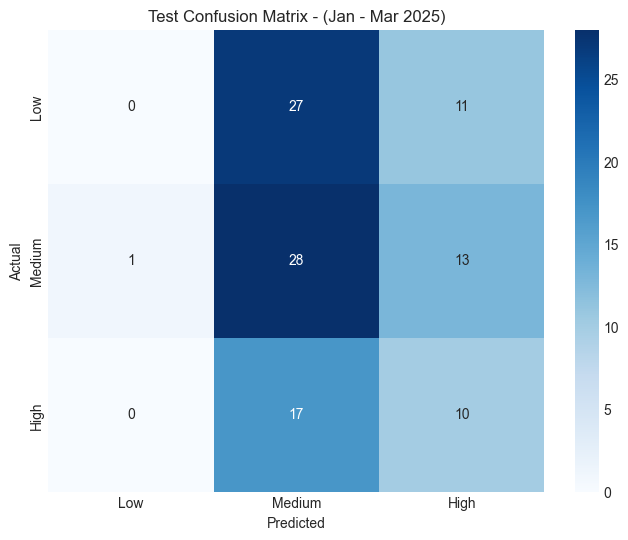


=== Backtesting Current Data Results ===


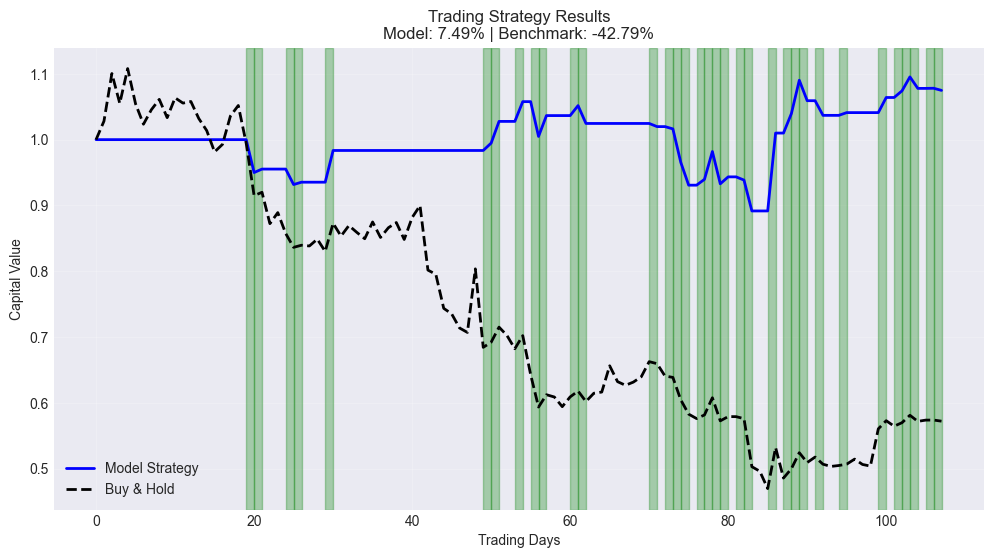

Average Daily Return: 0.09%
Percent of Days Invested: 31.78%
Model Return: 7.49%
Benchmark Return: -42.79%
Average Daily Return: 0.09%
Percent of days invested: 31.78%


In [11]:
accuracy_current = accuracy_score(y_current_true, current_predictions)
f1_current = f1_score(y_current_true, current_predictions, average='weighted')

print(f"\nCurrent Data Metrics:")
print(f"Accuracy: {accuracy_current:.4f}")
print(f"F1 Score: {f1_current:.4f}")


# Confusion matrix for train set
plt.figure(figsize=(8, 6))
conf_matrix_train = confusion_matrix(y_current_true, current_predictions)
sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.title(f'Test Confusion Matrix - (Jan - Mar 2025)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\n=== Backtesting Current Data Results ===")
backtest_results_current = calculate_backtest_returns(current_predictions, price_deltas_current)
print(f"Model Return: {backtest_results_current['model_return']:.2f}%")
print(f"Benchmark Return: {backtest_results_current['benchmark_return']:.2f}%")
print(f"Average Daily Return: {backtest_results_current['avg_daily_return']:.2f}%")
print(f"Percent of days invested: {backtest_results_current['percent_days_invested']:.2f}%")

In [12]:
# # Whitepaper-style histogram and density plot for validator counts (2021-2022)
# plt.figure(figsize=(10, 5))
# sns.histplot(validator_agg['validator_count'], bins=30, color='black', stat='density', edgecolor='white')
# plt.title('Distribution of Validator Counts (2021-2022)', fontsize=14, fontweight='bold')
# plt.xlabel('Validator Count', fontsize=12)
# plt.ylabel('Density', fontsize=12)
# plt.grid(True, alpha=0.2)
# plt.tight_layout()
# plt.show()

# # Time series plot of validator counts (2021-2022) with 7-day smoothing
# plt.figure(figsize=(14, 5))
# validator_agg['validator_count'].plot(color='black', linewidth=1.5, label='Daily')
# validator_agg['validator_count'].rolling(window=7, min_periods=1).mean().plot(
#     color='red', linewidth=2, linestyle='--', label='7-Day SMA'
# )

# plt.title('Validator Count Over Time (2021-2022)', fontsize=14, fontweight='bold')
# plt.xlabel('Date', fontsize=12)
# plt.ylabel('Validator Count', fontsize=12)
# plt.grid(True, alpha=0.2)
# plt.legend()
# plt.tight_layout()
# plt.show()

# # Whitepaper-style histogram and density plot for whale average value (2021-2022)
# plt.figure(figsize=(10, 5))
# sns.histplot(whale_agg['whale_avg_valueEth'], bins=30, color='navy', stat='density', edgecolor='white')
# plt.title('Distribution of Whale Average Value (2021-2022)', fontsize=14, fontweight='bold')
# plt.xlabel('Whale Average Value (ETH)', fontsize=12)
# plt.ylabel('Density', fontsize=12)
# plt.grid(True, alpha=0.2)
# plt.tight_layout()
# plt.show()

# # Whitepaper-style histogram and density plot for whale variance (2021-2022)
# plt.figure(figsize=(10, 5))
# sns.histplot(whale_agg['whale_var_valueEth'], bins=30, color='teal', stat='density', edgecolor='white')
# plt.title('Distribution of Whale Value Variance (2021-2022)', fontsize=14, fontweight='bold')
# plt.xlabel('Whale Value Variance (ETH^2)', fontsize=12)
# plt.ylabel('Density', fontsize=12)
# plt.grid(True, alpha=0.2)
# plt.tight_layout()
# plt.show()

# # Time series plot of whale average and variance (2021-2022)
# plt.figure(figsize=(14, 5))
# whale_agg['whale_avg_valueEth'].plot(color='navy', linewidth=1.5, label='Whale Avg Value')
# whale_agg['whale_var_valueEth'].plot(color='teal', linewidth=1.5, label='Whale Value Variance', secondary_y=True)
# plt.title('Whale Average Value and Variance Over Time (2021-2022)', fontsize=14, fontweight='bold')
# plt.xlabel('Date', fontsize=12)
# plt.grid(True, alpha=0.2)
# plt.legend(loc='upper left')
# plt.tight_layout()
# plt.show()